In [24]:
import pandas
import matplotlib.pyplot as plt
data = pandas.read_csv('prices_round_1_day_0.csv',sep=';')
squid_ink=data[data['product']=="SQUID_INK"]

In [25]:
def gradient(point1,point2):
    return (point2[1]-point1[1])/(point2[0]-point1[0])

In [26]:
a = list(squid_ink['timestamp'])
b = list(squid_ink['ask_price_1'])
#print(a[1])
#print(b[1])
gradient([a[2],b[2]],[a[1],b[1]])


-0.02

In [27]:
def upOrDown(point1) :
    for i in range(9999) :
        gradient(point1,[])

In [28]:
# points = {}
# for idx, row in squid_ink.iterrows():
#     points[row['timestamp']] = row['ask_price_1']

# print(points)


In [ ]:
import pandas as pd

data = pd.read_csv('prices_round_1_day_0.csv',sep=';')
ink = data[data['product']=="SQUID_INK"]
change1 = [] # array containing increasing price points
change2 = [] # array containing decreasing price points
change = [] # array containing all price points, if increasing = 1, if stable = 0, if decreasing = -1
diffArray = []
for i in range(1,10000,1):
    curr = (ink.iloc[i]['ask_price_1'] + ink.iloc[i]['bid_price_1'])/2
    past = (ink.iloc[i-1]['ask_price_1'] + ink.iloc[i-1]['bid_price_1'])/2
    grad = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])/(ink.iloc[i]['timestamp']-ink.iloc[i-1]['timestamp'])
    diff = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])
    if grad < 0 :
        change2.append(1)
        change1.append(0)
        change.append(-1)
        diffArray.append(diff/2)
    elif grad > 0 :
        change1.append(1)
        change2.append(0)
        change.append(1)
        diffArray.append(diff/2)
    else :
        change1.append(0)
        change2.append(0)
        change.append(0)
        diffArray.append(0)

#print(change)

positive=[]
for j in range(len(change1)) :
    positive.append(squid_ink.iloc[j]['ask_price_1']*change1[j]+diffArray[j])
positive.append(0)
#print(positive)

negative = []
for k in range(len(change2)) :
    negative.append(squid_ink.iloc[k]['ask_price_1']*change2[k]+diffArray[k])
negative.append(0)
#print(negative)





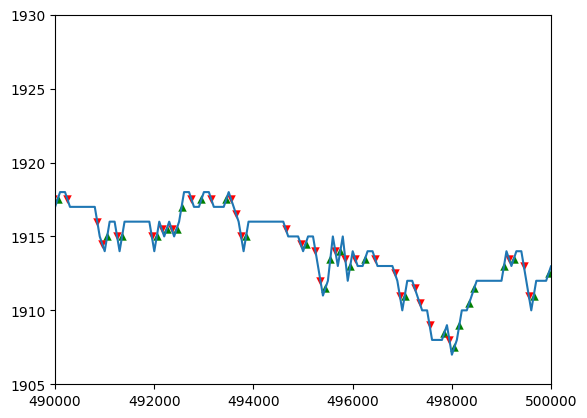

In [100]:

plt.plot(squid_ink['timestamp'],squid_ink['ask_price_1'])
plt.scatter(squid_ink['timestamp']+50,positive, color='g',marker='^',linewidths=0.05)
plt.scatter(squid_ink['timestamp']+50,negative, color='r',marker='v',linewidths=0.05)
ax = plt.gca()
ax.set_xlim([490000, 500000])
ax.set_ylim([1905, 1930])
plt.show()